# sample6 - GPU 確認・デバイス制御

TensorFlow は GPU を**自動検出・自動使用**します。  
PyTorch の `.to(device)` と異なり、明示的な指定は不要ですが、制御方法も学びます。

| ステップ | 内容 |
|----------|------|
| 1 | GPU の確認 |
| 2 | デバイスを明示的に指定 |
| 3 | GPU メモリ管理 |
| 4 | CPU / GPU の速度比較 |

## 1. GPU の確認

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # GPU を無効化して CPU で実行
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
import time
import numpy as np

# 利用可能なデバイス一覧
gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')

print("CPU:", cpus)
print("GPU:", gpus)

if gpus:
    print(f"\nGPU が {len(gpus)} 基利用可能です")
    for gpu in gpus:
        print(" -", gpu)
else:
    print("\nGPU は利用できません。CPU で実行します。")

CPU: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

GPU が 1 基利用可能です
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## 2. デバイスを明示的に指定

`tf.device()` で特定のデバイスを指定できます。

In [3]:
# GPU で演算
if gpus:
    with tf.device('/GPU:0'):
        a = tf.random.normal([1000, 1000])
        b = tf.random.normal([1000, 1000])
        c = tf.matmul(a, b)
    print("GPU 演算結果 shape:", c.shape)

# CPU で演算
with tf.device('/CPU:0'):
    a = tf.random.normal([1000, 1000])
    b = tf.random.normal([1000, 1000])
    c = tf.matmul(a, b)
print("CPU 演算結果 shape:", c.shape)

GPU 演算結果 shape: (1000, 1000)
CPU 演算結果 shape: (1000, 1000)


## 3. GPU メモリ管理

デフォルトでは TensorFlow が GPU メモリを全て確保します。メモリ増加（growth）設定を推奨します。

In [4]:
# メモリ増加設定（スクリプト冒頭で設定するのがベスト）
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("メモリ増加設定: 有効")
    except RuntimeError as e:
        # 初期化後には変更できない
        print("設定済み:", e)

設定済み: Physical devices cannot be modified after being initialized


## 4. CPU / GPU の速度比較

CPU 平均時間: 0.0933 秒
GPU 平均時間: 0.0001 秒
高速化: 1676.4 倍


/tmp/ipykernel_168600/3401213627.py:37: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168600/3401213627.py:37: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168600/3401213627.py:37: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168600/3401213627.py:37: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168600/3401213627.py:37: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168600/3401213627.py:37: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_168600/3401213627.py:37: UserWarning: Glyph 21015 (\N{CJK UNIFIED 

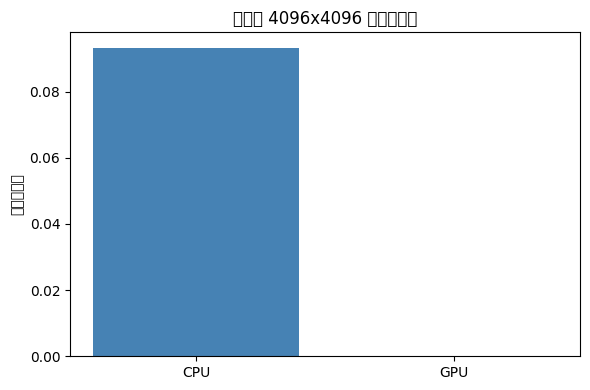

In [5]:
import matplotlib.pyplot as plt

size = 4096
a = tf.random.normal([size, size])
b = tf.random.normal([size, size])

# CPU
with tf.device('/CPU:0'):
    a_cpu = tf.identity(a)
    b_cpu = tf.identity(b)
    _ = tf.matmul(a_cpu, b_cpu)  # ウォームアップ
    start = time.time()
    for _ in range(5):
        tf.matmul(a_cpu, b_cpu)
    cpu_time = (time.time() - start) / 5

print(f"CPU 平均時間: {cpu_time:.4f} 秒")

if gpus:
    with tf.device('/GPU:0'):
        a_gpu = tf.identity(a)
        b_gpu = tf.identity(b)
        _ = tf.matmul(a_gpu, b_gpu)  # ウォームアップ
        start = time.time()
        for _ in range(5):
            tf.matmul(a_gpu, b_gpu)
        gpu_time = (time.time() - start) / 5

    print(f"GPU 平均時間: {gpu_time:.4f} 秒")
    print(f"高速化: {cpu_time / gpu_time:.1f} 倍")

    # 比較グラフ
    plt.figure(figsize=(6, 4))
    plt.bar(['CPU', 'GPU'], [cpu_time, gpu_time], color=['steelblue', 'orange'])
    plt.ylabel('時間（秒）')
    plt.title(f'行列積 {size}x{size} の速度比較')
    plt.tight_layout()
    plt.show()
else:
    print("GPU なし: CPU のみで実行")